# Please Enter your Name, Roll No, Section below:

R2114567 Surya


# Cheminformatics Lab (Google Colab)
## SMILES → 2D Structure → 3D Conformer Visualization (in Colab)

### Learning Objectives
By the end of this tutorial, students will be able to:
1. Explain what **SMILES** represents and why it is useful.
2. Convert **SMILES strings** into **2D molecular structures**.
3. Generate **basic molecular descriptors** (MW, logP, HBD/HBA, TPSA).
4. Create **3D conformers** using RDKit (ETKDG) and perform **energy minimization**.
5. Visualize **3D structures interactively** in Colab using **py3Dmol**.
6. Perform simple, chemistry‑aligned “mini tasks” (isomers, functional groups, property comparison).

---
### How to use this notebook
Run cells **top to bottom**. The exercises are marked as **🧩 Student Exercise**.


## 0) Setup: Install and import libraries

In [1]:
# @title

# Install RDKit + 3D viewer
!pip -q install rdkit py3Dmol

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, AllChem
import py3Dmol


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 42.6 MB/s eta 0:00:00



## 1) What is SMILES? (Quick concept)
**SMILES** = *Simplified Molecular Input Line Entry System*  
It encodes a molecule as a **text string**, describing atoms, bonds, branches, and rings.

Examples:
- Ethanol: `CCO`
- Benzene: `c1ccccc1`
- Acetic acid: `CC(=O)O`

In industry and research, SMILES is used to:
- store molecules in databases,
- run property predictions,
- build ML/QSAR datasets,
- generate 2D/3D structures programmatically.


## 2) SMILES → RDKit molecule (parsing and sanity checks)

In [2]:
# @title
def smiles_to_mol(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return mol

In [ ]:
test_smiles = ["CCO", "c1ccccc1", "CC(=O)O", "CCNC(CC)CC"]  # ethanol, benzene, acetic acid, triethylamine

In [ ]:
# @title
mols = [smiles_to_mol(s) for s in test_smiles]

# Show canonical SMILES (RDKit's standardized form)
for s in test_smiles:
    m = smiles_to_mol(s)
    print(s, "-> canonical:", Chem.MolToSmiles(m))


CCO -> canonical: CCO
c1ccccc1 -> canonical: c1ccccc1
CC(=O)O -> canonical: CC(=O)O
CCNC(CC)CC -> canonical: CCNC(CC)CC


## 3) Visualize 2D structures in Colab

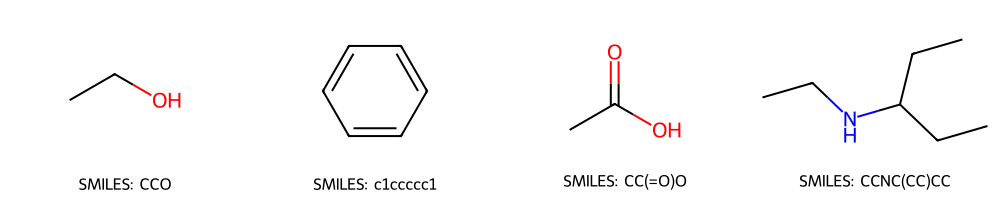

In [ ]:
# @title

Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(250, 200),
    legends=[f"SMILES: {s}" for s in test_smiles],
)



### 🧩 Student Exercise 1 (Easy)
Try 3–5 SMILES of your choice and display the grid.

Suggested SMILES:
- Propanol: `CCCO`
- Isopropanol: `CC(O)C`
- Cyclohexane: `C1CCCCC1`
- Aniline: `Nc1ccccc1`
- Aspirin: `CC(=O)Oc1ccccc1C(=O)O`

➡️ **Task:** Replace `my_smiles_list` below.


In [ ]:
my_smiles_list = ["CCCO", "CC(O)C", "c1ccccc1", "Nc1ccccc1", "CC(=O)Oc1ccccc1C(=O)O"]  # <-- edit these

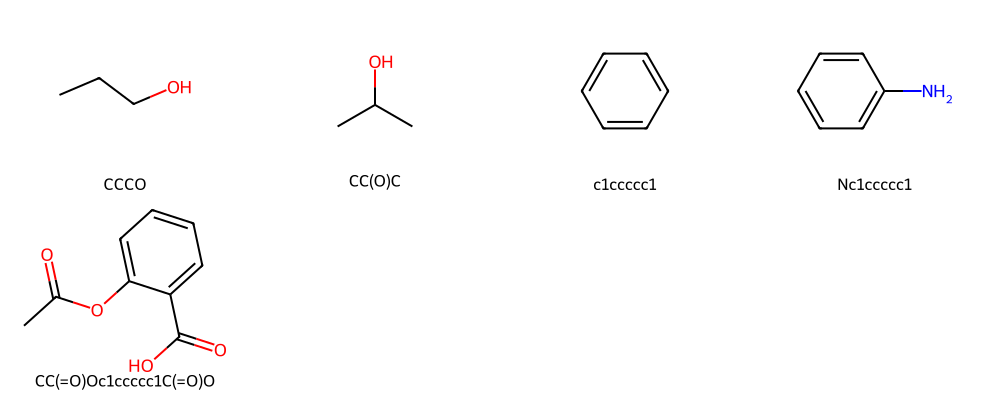

In [ ]:
# @title


my_mols = []
for s in my_smiles_list:
    try:
        my_mols.append(smiles_to_mol(s))
    except ValueError as e:
        print(e)

Draw.MolsToGridImage(
    my_mols,
    molsPerRow=4,
    subImgSize=(250, 200),
    legends=[f"{s}" for s in my_smiles_list],
)



## 4) Compute basic molecular properties (descriptors)
We will compute:
- Molecular weight (MW)
- logP: Partition Coefficient (Hydrophobicity) = log[Concentration in water/ Concentration in octanol] (Crippen)
- H-bond donors (HBD) and acceptors (HBA)
- Total surface area of polar atoms (O, N, S) in a molecule (TPSA)


In [ ]:
# @title

def basic_descriptors(smiles: str):
    m = smiles_to_mol(smiles)
    return {
        "SMILES": smiles,
        "Canonical": Chem.MolToSmiles(m),
        "MW": round(Descriptors.MolWt(m), 2),
        "logP": round(Descriptors.MolLogP(m), 2),
        "HBD": rdMolDescriptors.CalcNumHBD(m),
        "HBA": rdMolDescriptors.CalcNumHBA(m),
        "TPSA": round(rdMolDescriptors.CalcTPSA(m), 2),
    }

df = pd.DataFrame([basic_descriptors(s) for s in my_smiles_list])
df


,SMILES,Canonical,MW,logP,HBD,HBA,TPSA
0,CCCO,CCCO,60.10,0.39,1,1,20.23
1,CC(O)C,CC(C)O,60.10,0.39,1,1,20.23
2,c1ccccc1,c1ccccc1,78.11,1.69,0,0,0.00
3,Nc1ccccc1,Nc1ccccc1,93.13,1.27,1,1,26.02
4,CC(=O)Oc1ccccc1C(=O)O,CC(=O)Oc1ccccc1C(=O)O,180.16,1.31,1,3,63.60



### 🧩 Student Exercise 2 (Objective, not tough)
Compare two **isomers**:
- n‑butanol: `CCCCO`
- tert‑butanol: `CC(C)(C)O`

➡️ **Question:** Do isomers always have the same MW? What changes (logP, TPSA, HBD/HBA)?


In [ ]:

isomers = ["CCCCO", "CC(C)(C)O" ] # <-- edit these
pd.DataFrame([basic_descriptors(s) for s in isomers])


,SMILES,Canonical,MW,logP,HBD,HBA,TPSA
0,CCCCO,CCCCO,74.12,0.78,1,1,20.23
1,CC(C)(C)O,CC(C)(C)O,74.12,0.78,1,1,20.23



## 5) Generate 3D structures (conformers) with RDKit
Steps:
1. Add explicit hydrogens
2. Embed a 3D conformer (ETKDG)
3. Optimize geometry using a force field (UFF)

Then we’ll visualize using **py3Dmol**.


In [ ]:
# @title

def smiles_to_3d_mol(smiles: str, seed: int = 42):
    m = smiles_to_mol(smiles)
    m = Chem.AddHs(m)
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    ok = AllChem.EmbedMolecule(m, params)
    if ok != 0:
        raise RuntimeError(f"3D embedding failed for: {smiles}")
    AllChem.UFFOptimizeMolecule(m, maxIters=200)
    return m

def view_3d(mol, style="stick"):
    mb = Chem.MolToMolBlock(mol)
    v = py3Dmol.view(width=450, height=350)
    v.addModel(mb, "mol")
    v.setStyle({style: {}})
    v.zoomTo()
    return v



In [ ]:

mol3d = smiles_to_3d_mol("CCO")  # ethanol
view_3d(mol3d, style="stick")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


### 3D Visualization Styles
Try different styles:
- `"stick"`
- `"sphere"`
- `"line"`


In [ ]:

mol3d_benzene = smiles_to_3d_mol("CCO")
view_3d(mol3d_benzene, style="stick") # <---- edit stick by sphere


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


### 🧩 Student Exercise 3 (Fun + Visual)
Choose one molecule and visualize in 3D:
- Caffeine: `Cn1cnc2c1c(=O)n(C)c(=O)n2C`


➡️ **Task:** Visualize in 3D with at least **two** styles.


In [ ]:

drug_smiles = "Cn1cnc2c1c(=O)n(C)c(=O)n2C"  # caffeine (edit the smiles in quotes)
drug3d = smiles_to_3d_mol(drug_smiles)
view_3d(drug3d, style="stick")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:

view_3d(drug3d, style="stick")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 6) Student activity Mini‑Project: SMILES list → Table + 2D + 3D
Provide a list of SMILES and automatically:
- validate them,
- compute descriptors,
- show 2D grid,
- show 3D for the first molecule.


#Molecule 1 — “The Pain Reliever”
CC(=O)OC1=CC=CC=C1C(=O)O


👉 Questions:

How many oxygen atoms are present?

Does this molecule contain an aromatic ring?

What common medicine is this?

In [ ]:
 # 2d Structure here

In [ ]:
# 3d Structure here

In [ ]:
# Descriptor here

#Answer the questions here:

#Molecule 2 — “The Happy Molecule”
CN1CCC[C@H]1C2=CN=CC=C2


👉 Questions:

How many nitrogen atoms are present?

Is this molecule likely polar?

Which neurotransmitter does it resemble?

In [ ]:
 # 2d Structure here

In [ ]:
 # 3d Structure here

In [ ]:
# Descriptor here

#Answer the questions here:

#Molecule 3 — “The Energy Booster”
Cn1cnc2c1c(=O)n(C)c(=O)n2C


👉 Questions:

How many rings are present?

How many nitrogen atoms?

Why is this molecule biologically active?

In [ ]:
 # 2d Structure here

In [ ]:
# 3d Structure here

In [ ]:
# Descriptor here

#Answer the questions here:

#Molecule 4 — “The Plastic Builder”
C=C


👉 Questions:

What polymer can be made from this molecule?

Is it saturated or unsaturated?

In [ ]:
 # 2d Structure here

In [ ]:
# 3d Structure here

In [ ]:
# Descriptor here

#Answer the questions here:

#Molecule 5 — “The DNA Base”
C1=NC=NC2=C1N=CN2


👉 Questions:

How many rings are fused?

What class of biomolecule does this belong to?

In [ ]:
 # 2d Structure here

In [ ]:
# 3d Structure here

In [ ]:
# Descriptor here

#Answer the questions here:


---
## ✅ Auto‑Graded MCQ Quiz (Single Attempt)

**Rules**
- You have **only one attempt**.
- After you click **Submit**, your choices will be **locked** and cannot be changed.

> Tip: Run this cell only when you're ready to submit.


In [ ]:
# @title

# Auto-graded MCQ quiz (single attempt) for Cheminformatics: SMILES → 2D → 3D
# Colab/Jupyter: uses ipywidgets. Single attempt enforced with a local JSON file.

import json, os, datetime
import ipywidgets as widgets
from IPython.display import display, clear_output

SUBMISSION_FILE = "cheminfo_mcq_submission.json"

questions = [
    {
        "q": "1) What does a SMILES string represent?",
        "options": [
            "A 3D coordinate file for a molecule",
            "A text-based representation of molecular structure (atoms/bonds)",
            "A list of atomic masses only",
            "A spectroscopy peak table"
        ],
        "answer": 1
    },
    {
        "q": "2) In SMILES, what do lowercase 'c' atoms usually indicate? (e.g., c1ccccc1)",
        "options": [
            "Aliphatic carbon atoms",
            "A charged carbon atom",
            "Aromatic carbon atoms",
            "Carbon in CO2 only"
        ],
        "answer": 2
    },
    {
        "q": "3) Why do we generate 3D conformers for a molecule?",
        "options": [
            "To change the molecular formula",
            "To visualize and approximate realistic 3D shapes used in docking/ML/geometry",
            "To guarantee the molecule is aromatic",
            "To remove all hydrogens permanently"
        ],
        "answer": 1
    },
    {
        "q": "4) Which descriptor is most directly related to molecular polarity in this tutorial?",
        "options": [
            "Molecular Weight (MW)",
            "TPSA (Topological Polar Surface Area)",
            "Number of rings",
            "Number of carbon atoms only"
        ],
        "answer": 1
    },
    {
        "q": "5) A catalyst-like analogy: RDKit force-field optimization (UFF) is used to:",
        "options": [
            "Find a lower-energy (more reasonable) geometry",
            "Change the equilibrium constant of a reaction",
            "Convert SMILES into IUPAC name exactly",
            "Compute NMR spectra"
        ],
        "answer": 0
    },
    {
        "q": "6) Do isomers always have the same molecular weight (MW)?",
        "options": [
            "Yes, if they have the same molecular formula",
            "No, MW is always different for isomers",
            "Only if they are aromatic",
            "Only if they are polar"
        ],
        "answer": 0
    },
    {
        "q": "7) If RDKit cannot parse a SMILES, it usually means:",
        "options": [
            "The molecule is too large to exist",
            "The SMILES is invalid or contains an error",
            "RDKit cannot handle any rings",
            "The molecule has no atoms"
        ],
        "answer": 1
    },
    {
        "q": "8) In the 3D viewer (py3Dmol), which style shows atoms as spheres?",
        "options": [
            "stick",
            "line",
            "sphere",
            "grid"
        ],
        "answer": 2
    },
]

# If already submitted, lock immediately
if os.path.exists(SUBMISSION_FILE):
    with open(SUBMISSION_FILE, "r") as f:
        data = json.load(f)
    display(widgets.HTML(
        f"<h3>✅ Quiz already submitted — locked.</h3>"
        f"<p><b>Submitted:</b> {data.get('submitted_at','')}</p>"
        f"<p><b>Score:</b> {data.get('score','')} / {data.get('total','')}</p>"
        f"<p><b>Saved file:</b> {SUBMISSION_FILE}</p>"
    ))
else:
    radios = []
    blocks = []
    for item in questions:
        r = widgets.RadioButtons(
            options=[(opt, i) for i, opt in enumerate(item["options"])],
            layout=widgets.Layout(width="100%"),
            disabled=False
        )
        radios.append(r)
        blocks.append(widgets.VBox([widgets.HTML(f"<b>{item['q']}</b>"), r]))

    submit_btn = widgets.Button(description="Submit (Single Attempt)", button_style="danger")
    out = widgets.Output()

    def lock_all():
        for r in radios:
            r.disabled = True
        submit_btn.disabled = True

    def on_submit(_):
        if os.path.exists(SUBMISSION_FILE):
            with out:
                clear_output()
                print("⚠️ Already submitted and locked.")
            lock_all()
            return

        responses = []
        score = 0
        for r, item in zip(radios, questions):
            sel = r.value
            responses.append(sel)
            if sel == item["answer"]:
                score += 1

        payload = {
            "submitted_at": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "score": score,
            "total": len(questions),
            "responses": responses
        }
        with open(SUBMISSION_FILE, "w") as f:
            json.dump(payload, f, indent=2)

        lock_all()
        with out:
            clear_output()
            print(f"✅ Submitted. Score: {score} / {len(questions)}")
            print(f"Saved to: {SUBMISSION_FILE}")
            print("🔒 Answers are now locked (single attempt).")

    submit_btn.on_click(on_submit)
    display(widgets.VBox(blocks + [submit_btn, out]))



## 7) Creative Part (optional)

Generate **multiple conformers** for one molecule and compare energies.


In [ ]:
# @title

# Optional Extension: multiple conformers + energies
smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"  # ibuprofen
m = Chem.AddHs(smiles_to_mol(smiles))

params = AllChem.ETKDGv3()
params.randomSeed = 7
conf_ids = AllChem.EmbedMultipleConfs(m, numConfs=10, params=params)

energies = []
for cid in conf_ids:
    AllChem.UFFOptimizeMolecule(m, confId=cid, maxIters=200)
    ff = AllChem.UFFGetMoleculeForceField(m, confId=cid)
    energies.append(ff.CalcEnergy())

pd.DataFrame({"ConformerID": list(conf_ids), "UFF_Energy": energies}).sort_values("UFF_Energy").reset_index(drop=True)


,ConformerID,UFF_Energy
0,5,22.139140
1,1,22.139140
2,6,22.139201
3,9,22.139201
4,8,22.142567
5,0,22.143311
6,4,22.386746
7,2,22.387818
8,3,22.390049
9,7,22.390049
